# Exploratory Analysis of Policy Brief Results

This notebook loads the generated outputs from `output/` and performs descriptive exploratory analysis for documents, frames, and policy recommendations.

In [1]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display

In [2]:
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'output'

documents = pd.read_parquet(OUTPUT_DIR / 'documents.parquet')
frames = pd.read_parquet(OUTPUT_DIR / 'frames.parquet')
recommendations = pd.read_parquet(OUTPUT_DIR / 'recommendations.parquet')

documents['creation_date'] = pd.to_datetime(documents['creation_date'], errors='coerce')
documents['processing_timestamp'] = pd.to_datetime(documents['processing_timestamp'], errors='coerce')
documents['creation_year'] = documents['creation_date'].dt.year
documents['recommendations_per_100_pages'] = np.where(
    documents['page_count'] > 0,
    documents['recommendations_count'] / documents['page_count'] * 100,
    np.nan,
)
documents['frames_present_share'] = np.where(
    (documents['frames_present'] + documents['frames_absent']) > 0,
    documents['frames_present'] / (documents['frames_present'] + documents['frames_absent']),
    np.nan,
)
documents['frame_density_per_100_pages'] = np.where(
    documents['page_count'] > 0,
    documents['frames_present'] / documents['page_count'] * 100,
    np.nan,
)

frames = frames.merge(documents[['doc_id', 'creation_year', 'file_name']], on='doc_id', how='left')
recommendations = recommendations.merge(
    documents[['doc_id', 'creation_year', 'file_name', 'page_count']],
    on='doc_id',
    how='left',
)

print(f'Documents: {len(documents)}')
print(f'Frame assessments: {len(frames)}')
print(f'Recommendations: {len(recommendations)}')

Documents: 34
Frame assessments: 272
Recommendations: 153


## Data Quality and Coverage

Check the main corpus totals, missingness, and the distribution of key document-level outputs.

,dataset,rows,columns,missing_cells
0,documents,34,35,68
1,frames,272,12,0
2,recommendations,153,16,0


,missing_values
flesch_kincaid_grade,34
flesch_reading_ease,34
doc_id,0
file_name,0
file_path,0
title,0
author,0
processing_timestamp,0
processing_duration_seconds,0
creation_date,0


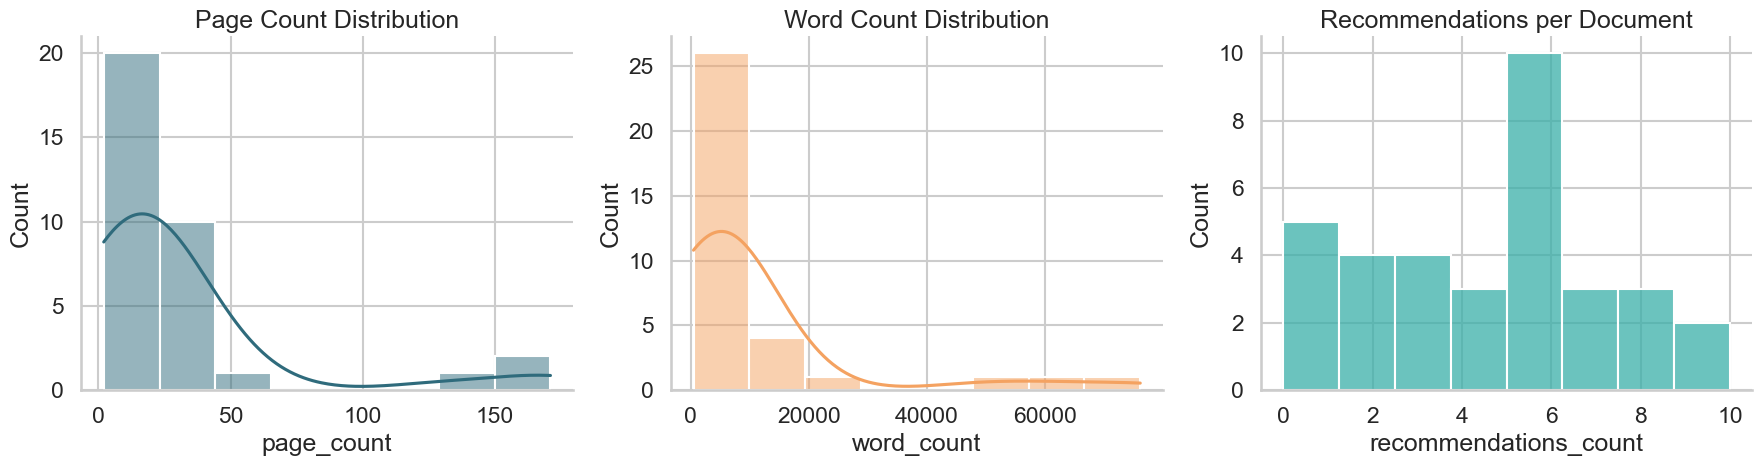

In [3]:
summary = pd.DataFrame({
    'dataset': ['documents', 'frames', 'recommendations'],
    'rows': [len(documents), len(frames), len(recommendations)],
    'columns': [documents.shape[1], frames.shape[1], recommendations.shape[1]],
    'missing_cells': [documents.isna().sum().sum(), frames.isna().sum().sum(), recommendations.isna().sum().sum()],
})
display(summary)

display(documents.isna().sum().sort_values(ascending=False).head(10).rename('missing_values').to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(documents['page_count'], bins=8, kde=True, ax=axes[0], color='#2F6B7C')
axes[0].set_title('Page Count Distribution')
sns.histplot(documents['word_count'], bins=8, kde=True, ax=axes[1], color='#F4A261')
axes[1].set_title('Word Count Distribution')
sns.histplot(documents['recommendations_count'], bins=8, kde=False, ax=axes[2], color='#3AAFA9')
axes[2].set_title('Recommendations per Document')
plt.tight_layout()
plt.show()

## Document-Level Exploration

These views highlight corpus composition over time, structural variation, and how document size relates to extracted outputs.

,doc_id,file_name,creation_year,page_count,word_count,frames_present,recommendations_count,text_extraction_quality,likely_scanned
23,doc_35,35.pdf,2017,42,8847,3,10,0.716488,False
16,doc_26,26.pdf,2022,18,6949,2,9,1.000000,False
22,doc_4,4.pdf,2018,3,1247,3,8,1.000000,False
13,doc_27,27.pdf,2022,5,1180,1,8,0.863700,False
26,doc_6_6,6_6.pdf,2022,3,1368,0,8,1.000000,False
1,doc_10,10.pdf,2022,170,76047,7,7,1.000000,False
18,doc_30,30.pdf,2018,24,7979,2,7,1.000000,False
27,doc_6_4,6_4.pdf,2021,3,1332,0,7,1.000000,False
3,doc_14,14.pdf,2021,2,489,2,6,0.863750,False
6,doc_16,16.pdf,2017,29,9579,1,6,1.000000,False


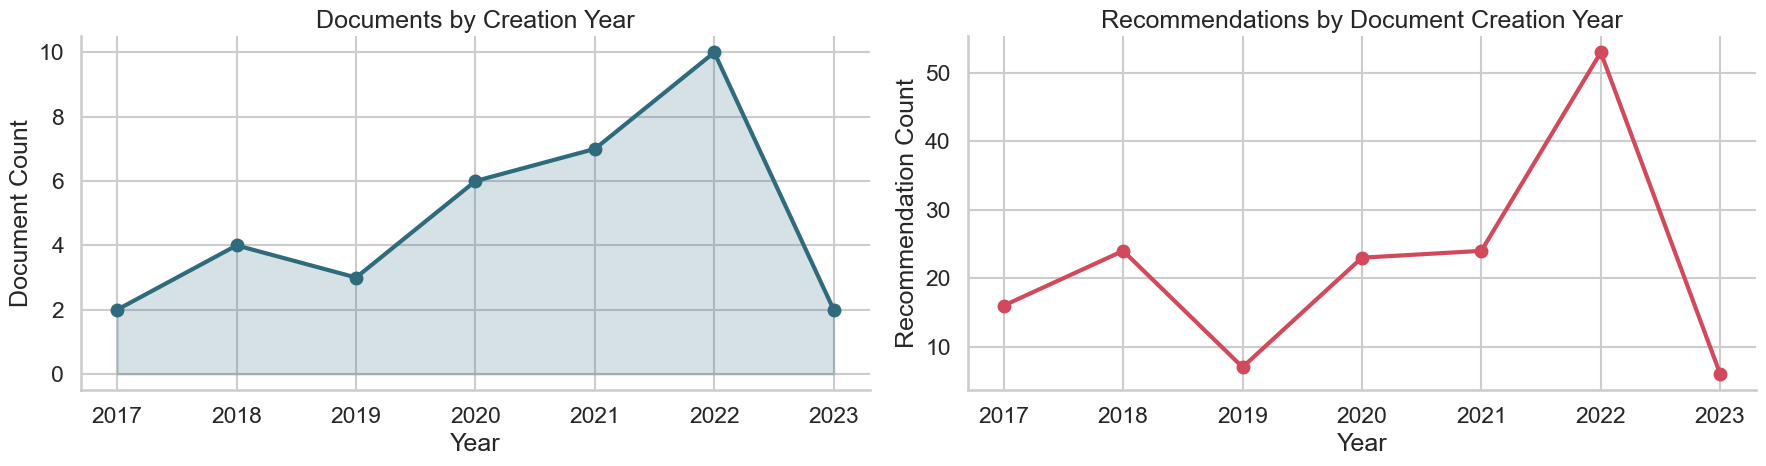

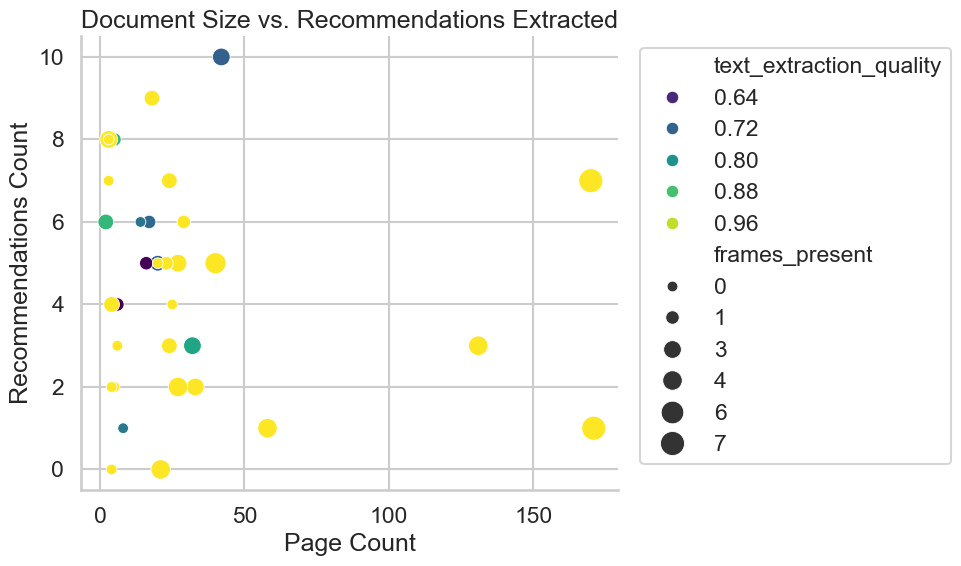

In [4]:
display(
    documents[[
        'doc_id', 'file_name', 'creation_year', 'page_count', 'word_count',
        'frames_present', 'recommendations_count', 'text_extraction_quality', 'likely_scanned'
    ]]
    .sort_values(['recommendations_count', 'frames_present'], ascending=False)
    .head(10)
)

docs_per_year = documents.dropna(subset=['creation_year']).groupby('creation_year').size()
recs_per_year = recommendations.dropna(subset=['creation_year']).groupby('creation_year').size()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
docs_per_year.plot(ax=axes[0], marker='o', linewidth=3, color='#2F6B7C')
axes[0].fill_between(docs_per_year.index, docs_per_year.values, alpha=0.2, color='#2F6B7C')
axes[0].set_title('Documents by Creation Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Document Count')

recs_per_year.plot(ax=axes[1], marker='o', linewidth=3, color='#D1495B')
axes[1].set_title('Recommendations by Document Creation Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Recommendation Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=documents,
    x='page_count',
    y='recommendations_count',
    size='frames_present',
    hue='text_extraction_quality',
    palette='viridis',
    sizes=(60, 300),
)
plt.title('Document Size vs. Recommendations Extracted')
plt.xlabel('Page Count')
plt.ylabel('Recommendations Count')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Framing Analysis

The framing section covers prevalence, confidence, temporal patterns, and co-occurrence of present frames within the same document.

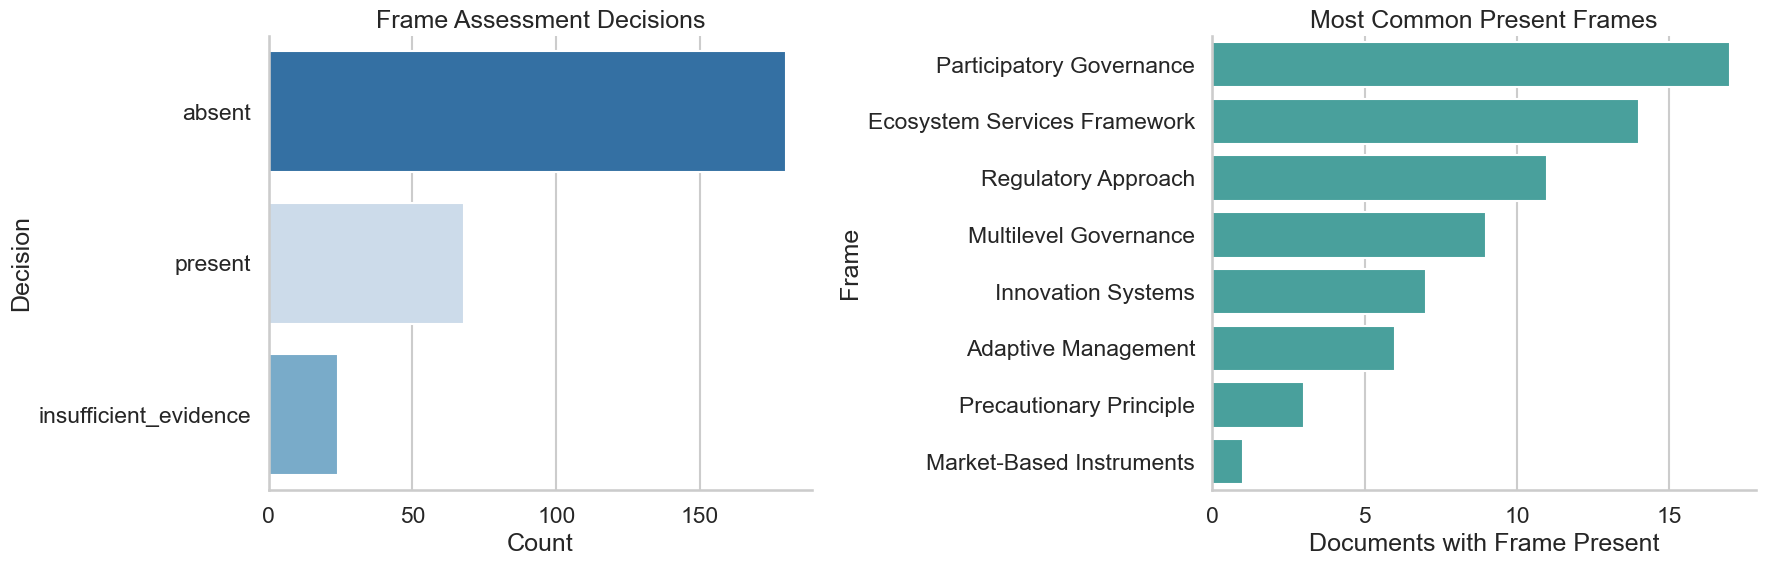

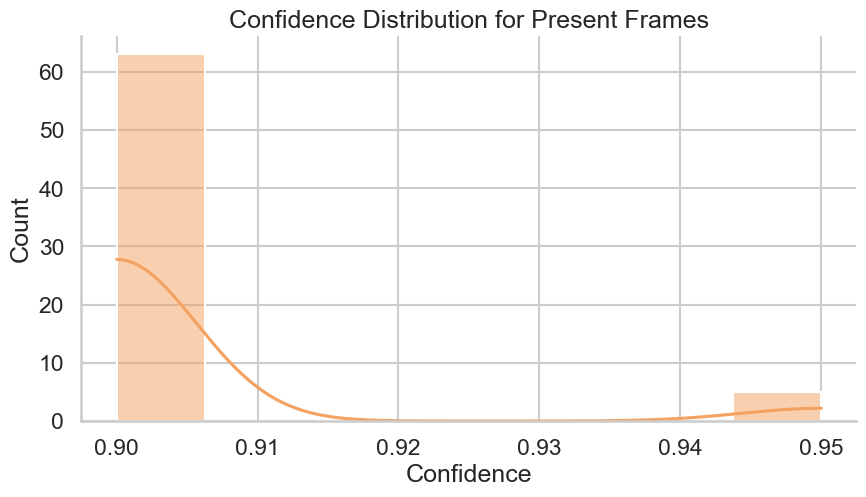

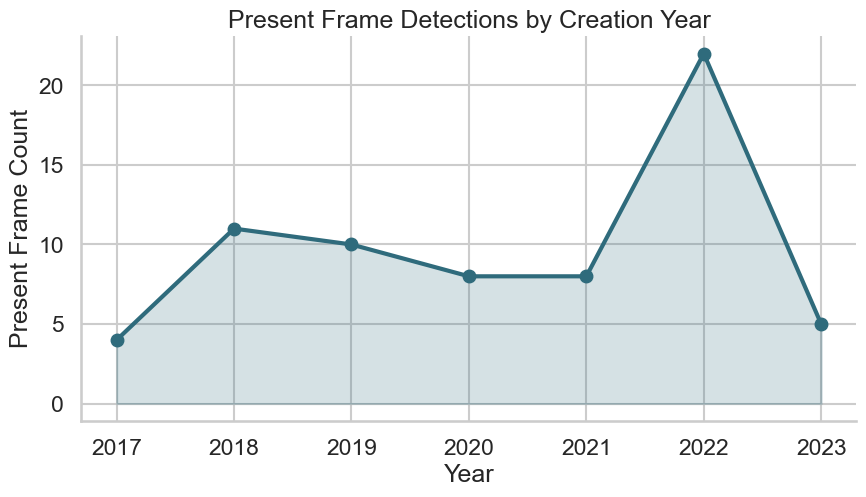

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(data=frames, y='decision', order=frames['decision'].value_counts().index, ax=axes[0], palette='Blues_r', hue='decision', legend=False)
axes[0].set_title('Frame Assessment Decisions')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Decision')

present_frames = frames.loc[frames['decision'] == 'present', 'frame_label'].value_counts()
sns.barplot(x=present_frames.values, y=present_frames.index, ax=axes[1], color='#3AAFA9')
axes[1].set_title('Most Common Present Frames')
axes[1].set_xlabel('Documents with Frame Present')
axes[1].set_ylabel('Frame')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(frames.loc[frames['decision'] == 'present', 'confidence'], bins=8, kde=True, color='#F4A261')
plt.title('Confidence Distribution for Present Frames')
plt.xlabel('Confidence')
plt.show()

present_frames_year = (
    frames.loc[frames['decision'] == 'present']
    .dropna(subset=['creation_year'])
    .groupby('creation_year')
    .size()
)
plt.figure(figsize=(10, 5))
present_frames_year.plot(marker='o', linewidth=3, color='#2F6B7C')
plt.fill_between(present_frames_year.index, present_frames_year.values, alpha=0.2, color='#2F6B7C')
plt.title('Present Frame Detections by Creation Year')
plt.xlabel('Year')
plt.ylabel('Present Frame Count')
plt.show()

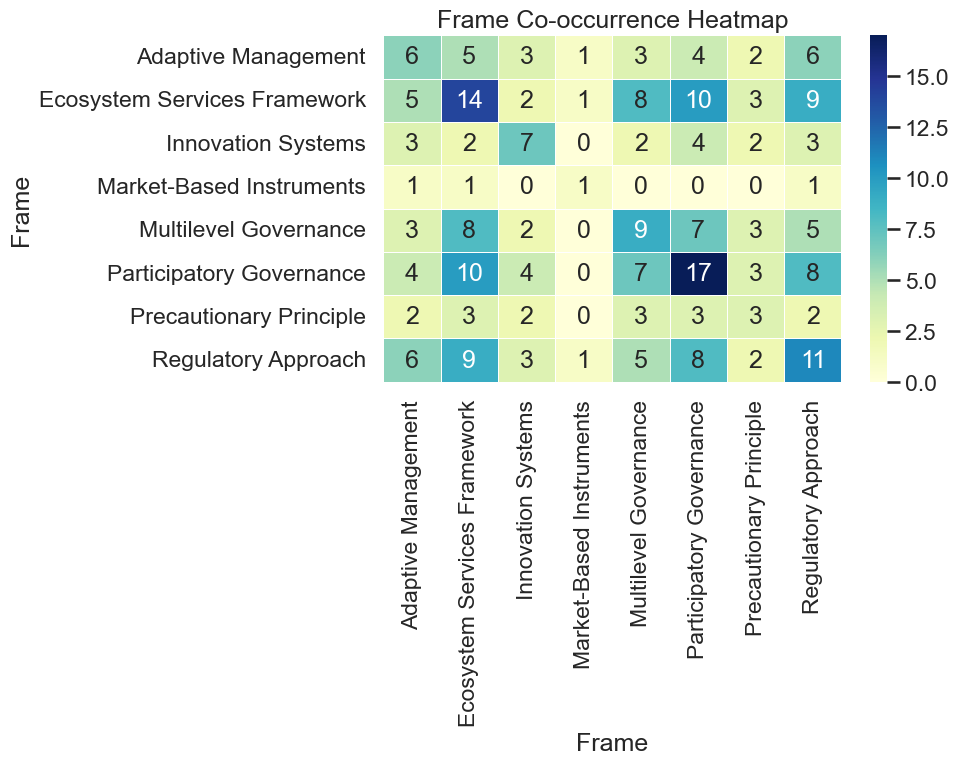

,documents_with_frame
frame_label,
Participatory Governance,17.0
Ecosystem Services Framework,14.0
Regulatory Approach,11.0
Multilevel Governance,9.0
Innovation Systems,7.0
Adaptive Management,6.0
Precautionary Principle,3.0
Market-Based Instruments,1.0


In [6]:
present_matrix = (
    frames.assign(is_present=frames['decision'].eq('present').astype(int))
    .pivot_table(index='doc_id', columns='frame_label', values='is_present', fill_value=0)
)
cooccurrence = present_matrix.T.dot(present_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Frame Co-occurrence Heatmap')
plt.xlabel('Frame')
plt.ylabel('Frame')
plt.tight_layout()
plt.show()

display(present_matrix.sum().sort_values(ascending=False).rename('documents_with_frame').to_frame())

## Policy Recommendation Analysis

This section summarizes recommendation types, actors, spatial scope, urgency, domain emphasis, and recommendation language.

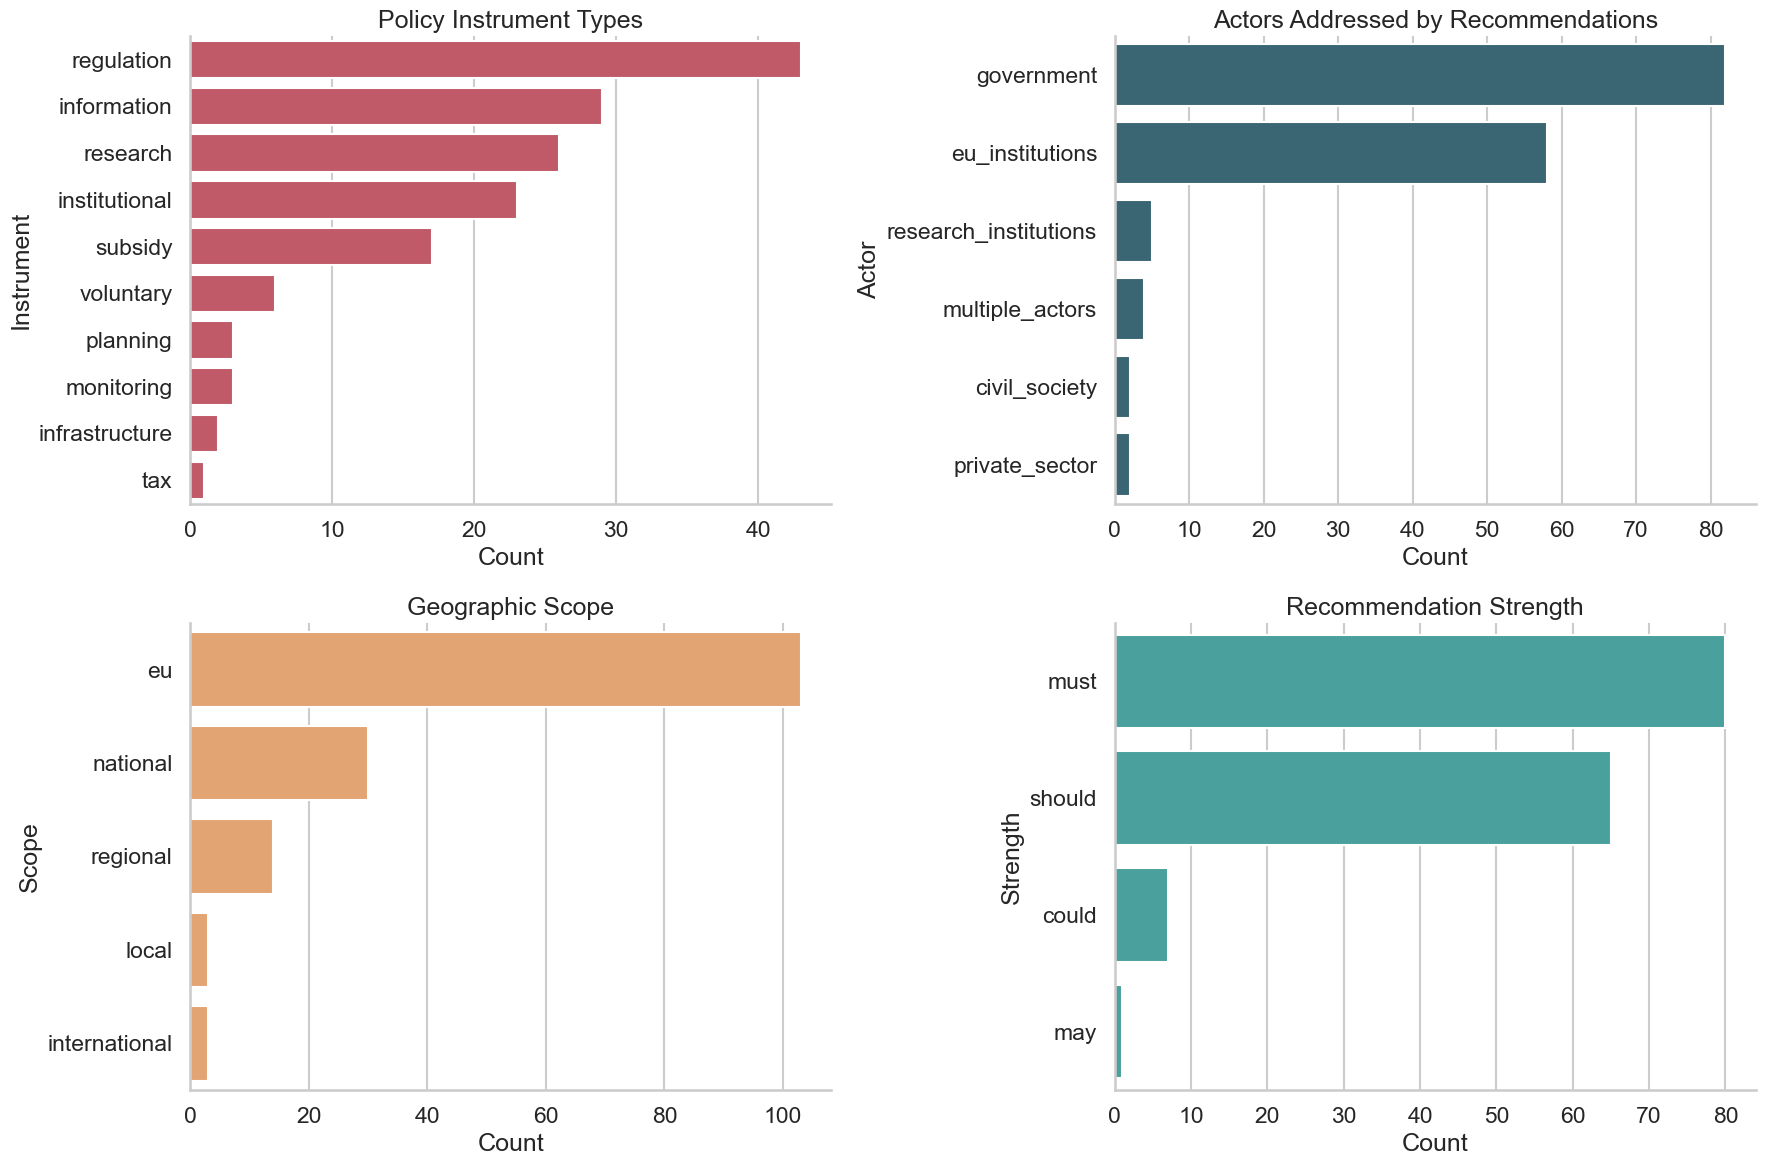

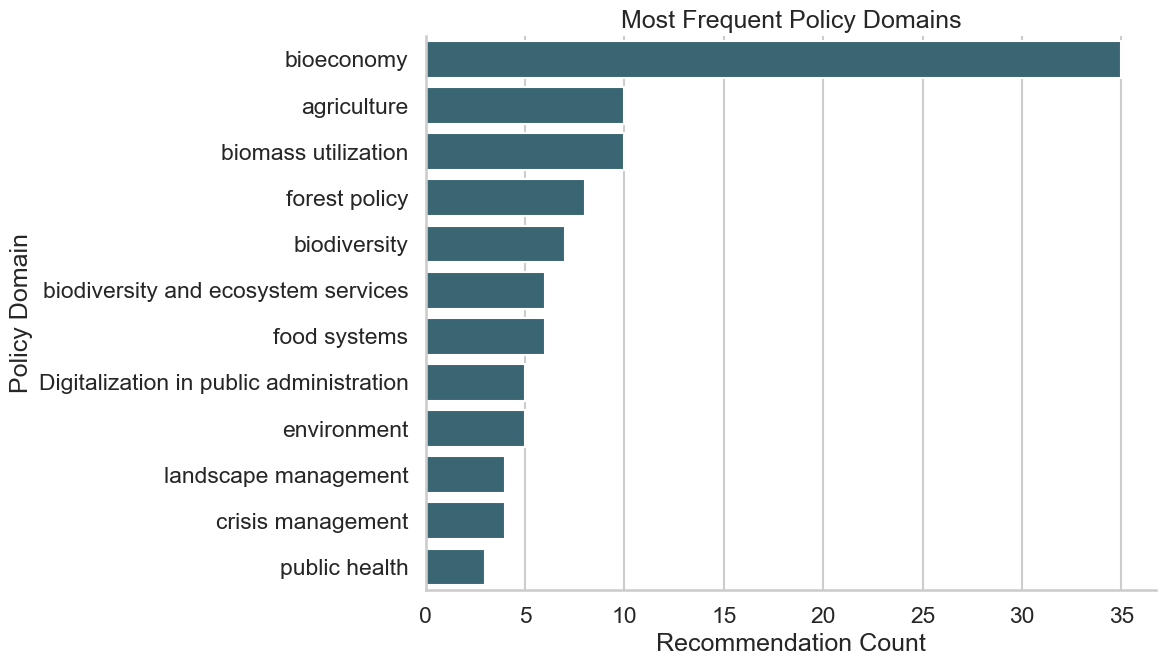

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.countplot(data=recommendations, y='instrument_type', order=recommendations['instrument_type'].value_counts().index, ax=axes[0, 0], color='#D1495B')
axes[0, 0].set_title('Policy Instrument Types')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Instrument')

sns.countplot(data=recommendations, y='actor', order=recommendations['actor'].value_counts().index, ax=axes[0, 1], color='#2F6B7C')
axes[0, 1].set_title('Actors Addressed by Recommendations')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Actor')

sns.countplot(data=recommendations, y='geographic_scope', order=recommendations['geographic_scope'].value_counts().index, ax=axes[1, 0], color='#F4A261')
axes[1, 0].set_title('Geographic Scope')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Scope')

sns.countplot(data=recommendations, y='strength', order=recommendations['strength'].value_counts().index, ax=axes[1, 1], color='#3AAFA9')
axes[1, 1].set_title('Recommendation Strength')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Strength')
plt.tight_layout()
plt.show()

top_domains = recommendations['policy_domain'].value_counts().head(12)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_domains.values, y=top_domains.index, color='#2F6B7C')
plt.title('Most Frequent Policy Domains')
plt.xlabel('Recommendation Count')
plt.ylabel('Policy Domain')
plt.tight_layout()
plt.show()

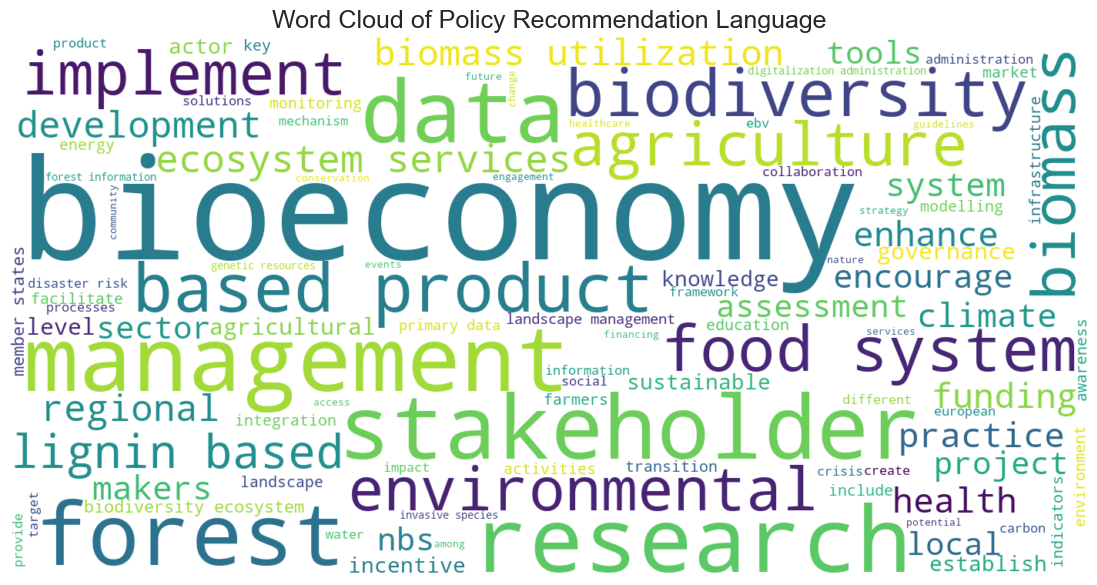

,doc_id,file_name,page_count,recommendations_count,recommendations_per_100_pages
3,doc_14,14.pdf,2,6,300.000000
22,doc_4,4.pdf,3,8,266.666667
26,doc_6_6,6_6.pdf,3,8,266.666667
27,doc_6_4,6_4.pdf,3,7,233.333333
13,doc_27,27.pdf,5,8,160.000000
24,doc_36,36.pdf,4,4,100.000000
10,doc_23,23.pdf,6,4,66.666667
25,doc_6_1,6_1.pdf,6,3,50.000000
31,doc_6_7,6_7.pdf,4,2,50.000000
16,doc_26,26.pdf,18,9,50.000000


In [8]:
stopwords = {
    'the', 'and', 'for', 'that', 'with', 'from', 'this', 'into', 'must', 'should', 'could', 'would',
    'their', 'there', 'have', 'has', 'been', 'being', 'more', 'than', 'such', 'through', 'across',
    'need', 'needs', 'policy', 'policies', 'recommend', 'recommendations', 'recommendation', 'use',
    'using', 'used', 'can', 'may', 'all', 'new', 'within', 'between', 'support', 'ensure', 'develop',
    'improve', 'promote', 'public', 'private', 'based', 'towards', 'also', 'these', 'those', 'them'
}

recommendation_text = (
    recommendations['action'].fillna('') + ' ' + recommendations['target'].fillna('') + ' ' + recommendations['policy_domain'].fillna('')
)
clean_text = ' '.join(recommendation_text.tolist()).lower()
tokens = re.findall(r'[a-z][a-z\-]{2,}', clean_text)
tokens = [token for token in tokens if token not in stopwords]

wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='viridis',
    max_words=100,
).generate(' '.join(tokens))

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Policy Recommendation Language')
plt.show()

display(
    documents[['doc_id', 'file_name', 'page_count', 'recommendations_count', 'recommendations_per_100_pages']]
    .sort_values('recommendations_per_100_pages', ascending=False)
    .head(10)
)

## Supplementary EDA

Additional exploratory views: metric correlations and documents with unusually high frame or recommendation density.

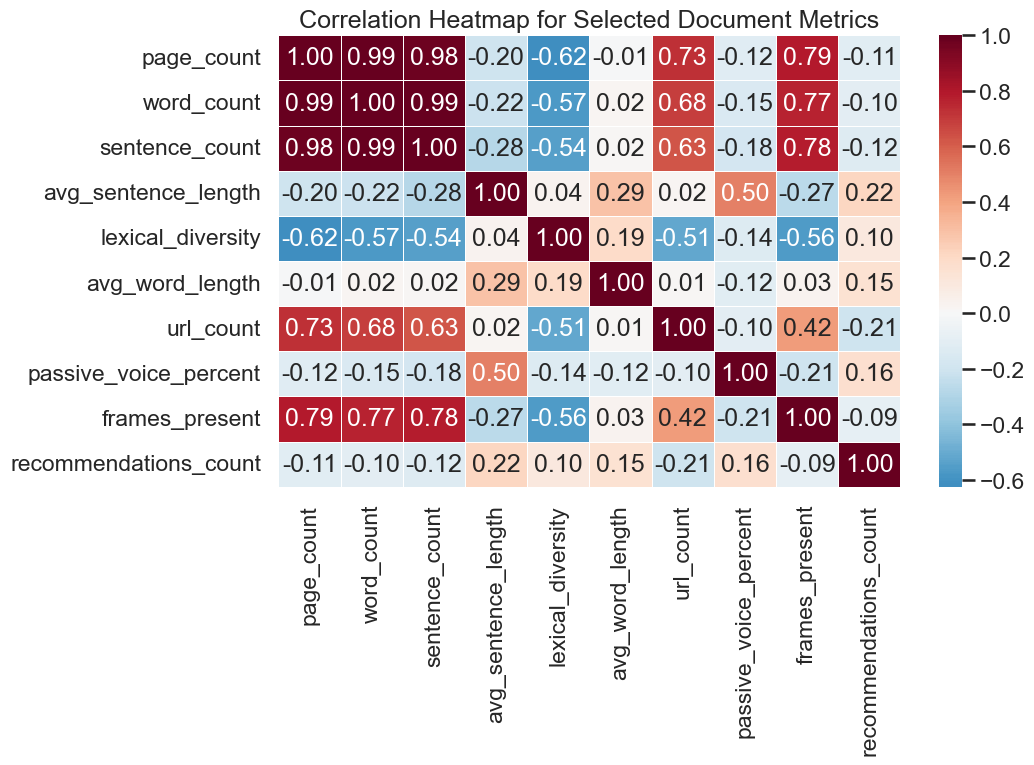

,doc_id,file_name,page_count,frames_present,frame_density_per_100_pages,recommendations_count,recommendations_per_100_pages
3,doc_14,14.pdf,2,2,100.000000,6,300.000000
22,doc_4,4.pdf,3,3,100.000000,8,266.666667
24,doc_36,36.pdf,4,2,50.000000,4,100.000000
13,doc_27,27.pdf,5,1,20.000000,8,160.000000
5,doc_15,15.pdf,21,4,19.047619,0,0.000000
10,doc_23,23.pdf,6,1,16.666667,4,66.666667
21,doc_33,33.pdf,27,4,14.814815,2,7.407407
11,doc_20,20.pdf,40,5,12.500000,5,12.500000
16,doc_26,26.pdf,18,2,11.111111,9,50.000000
9,doc_22,22.pdf,27,3,11.111111,5,18.518519


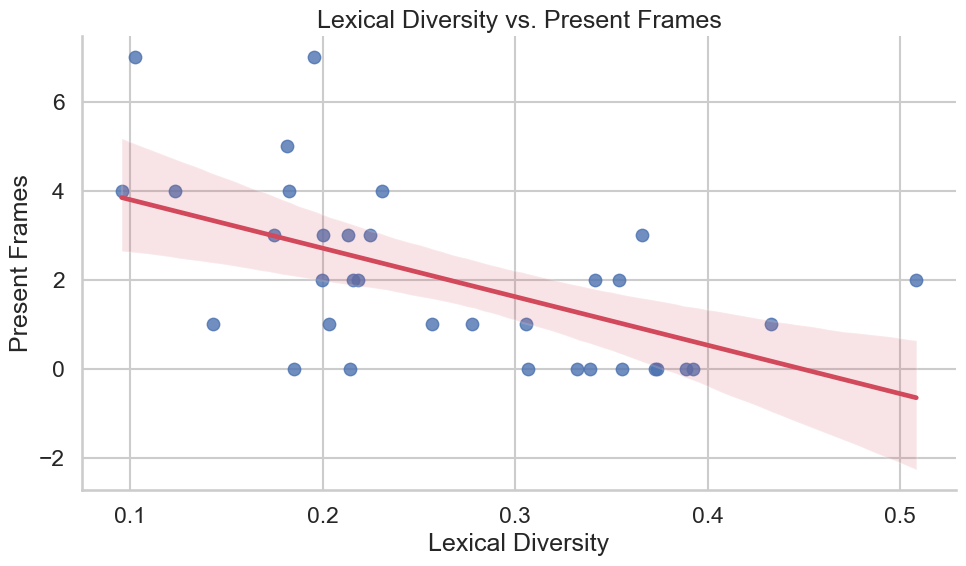

In [9]:
numeric_cols = [
    'page_count', 'word_count', 'sentence_count', 'avg_sentence_length', 'lexical_diversity',
    'avg_word_length', 'url_count', 'passive_voice_percent', 'frames_present', 'recommendations_count'
]
corr = documents[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap for Selected Document Metrics')
plt.tight_layout()
plt.show()

display(
    documents[[
        'doc_id', 'file_name', 'page_count', 'frames_present', 'frame_density_per_100_pages',
        'recommendations_count', 'recommendations_per_100_pages'
    ]]
    .sort_values(['frame_density_per_100_pages', 'recommendations_per_100_pages'], ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.regplot(data=documents, x='lexical_diversity', y='frames_present', scatter_kws={'s': 80, 'alpha': 0.8}, line_kws={'color': '#D1495B'})
plt.title('Lexical Diversity vs. Present Frames')
plt.xlabel('Lexical Diversity')
plt.ylabel('Present Frames')
plt.tight_layout()
plt.show()